# 16 — Partial Charge Probe

Split from the original combined "Attention Weights, Embeddings & Partial Charge Probe" notebook — this half covers the partial charge probe only. See notebook 15 for embedding/attention analysis.

## Why Probe?

A model can achieve reasonable ESP prediction by learning surface-level correlations without encoding meaningful chemistry. This probe checks whether the atom embeddings after Stage 1 message passing carry semantically meaningful representations: if a frozen-backbone probe can recover per-atom partial charges (which directly determine ESP) with high R², the model has implicitly learned the charge distribution required for ESP prediction.

- Train a frozen-backbone 3-layer MLP to predict per-atom partial charges from PQR files.
- Probe is trained on embeddings extracted at `after_mp` (after Stage 1 bond → radial message passing) or `after_encoder` (raw element + residue + bond-count embeddings, before any message passing).
- High R² at `after_mp` — with backbone frozen — means the bond and radial message passing rounds are enriching atom representations with local chemical context, not just the encoder lookup.
- Section 2b breaks accuracy down by chemical environment (backbone carbonyl C, aromatic N, hydroxyl O, carboxylate O, etc.) to identify which chemical roles the embeddings distinguish well and which are conflated.

## Key Findings (from the original combined run)

- **Partial charge R² = 0.9947** (RMSE = 0.020 e) across 20 test proteins — atom embeddings after Stage 1 encode the charge distribution at near-lookup accuracy from a simple frozen probe.
- Best-predicted environments: H atoms (RMSE=0.012), backbone amide N (RMSE=0.016).
- Hardest environments: aromatic C (RMSE=0.043, r=0.89) and carbonyl C backbone (RMSE=0.032, r=0.376). The low correlation for carbonyl C reflects near-zero charge variance (std=0.026 e across all backbone carbonyl carbons) — absolute error is small but correlation is undefined in the limit of no variance.

> **Note:** `PROBE_MODEL` below points at a checkpoint from the old pre-staged-ablation naming (`attention_both_batching`). Re-point this at the winning Phase 1-4 checkpoint once the staged ablation study concludes, and rerun.

In [6]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import (
    ELEMENT_NAMES,
    RESIDUE_NAMES,
    collect_attention_stats,
    collect_attention_stats_residue,
    compare_embedding_tables,
    embedding_cosine_sim,
    load_model_frozen,
    _load_graph,
)
from src.analysis.charge_probe import (
    ChargeProbe,
    evaluate_probe,
    extract_atom_embeddings,
    read_pqr_charges,
    read_pqr_atoms,
    train_probe,
)
from src.data.dataset import load_split_manifest
from src.models.attention_espn import AttentionESPN
from src.utils.config import get_data_root
from src.utils.paths import ProteinPaths

## Configuration

`PROBE_MODEL` is the backbone used for the charge probe. `PROBE_LAYER` controls whether the probe reads embeddings before or after Stage 1 message passing.

In [ ]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = get_data_root()

PROBE_MODEL  = CKPT_ROOT / "attention_both_batching"
PROBE_LAYER  = "after_mp"   # "after_encoder" or "after_mp"
PROBE_EPOCHS = 30
PROBE_LR     = 1e-3

print(f"PROBE_MODEL:   {PROBE_MODEL}  (exists: {PROBE_MODEL.exists()})")
print(f"PROBE_LAYER:   {PROBE_LAYER}")

---
## 2. Partial Charge Probe

Trains a small 3-layer MLP on top of **frozen** atom embeddings to predict per-atom partial charges from PQR files. No backbone weights are modified — any predictive power comes entirely from information already encoded in the frozen embeddings.

Partial charges are the direct source of ESP: the APBS solver computes ESP by treating each atom as a point charge at its partial charge value. If the frozen embeddings encode partial charges well, the model has implicitly learned the charge representation that determines the output it is being trained to predict.

Two extraction layers are available for comparison:

| Layer | Description |
|-------|-------------|
| `after_encoder` | Raw element + residue + bond-count embeddings — no message passing |
| `after_mp` | After Stage 1 bond → radial rounds — local chemical context incorporated |

A large R² gap between `after_encoder` and `after_mp` would show that Stage 1 message passing meaningfully enriches atom representations beyond the initial lookup.

In [12]:
if PROBE_MODEL.exists():
    probe_backbone, probe_ckpt = load_model_frozen(PROBE_MODEL, DEVICE)
    hidden_dim = probe_ckpt["model_config"]["hidden_dim"]
    n_frozen   = sum(1 for p in probe_backbone.parameters() if not p.requires_grad)
    print(f"Backbone: {probe_ckpt['model_name']}  hidden_dim={hidden_dim}  "
          f"{n_frozen} frozen params (should equal total)")
else:
    print(f"Checkpoint not found: {PROBE_MODEL}")

Backbone: attention  hidden_dim=256  56 frozen params (should equal total)


The probe MLP has 3 layers (hidden_dim → 128 → 64 → 1). All backbone parameters are frozen before training begins; only probe weights are updated. Training on 151 proteins for 30 epochs with MSE loss against PQR partial charges.

In [13]:
if not PROBE_MODEL.exists():
    print(f"Checkpoint not found: {PROBE_MODEL}")
else:
    train_ids, val_ids, test_ids = load_split_manifest(DATA_ROOT)
    print(f"Training probe on {len(train_ids)} proteins for {PROBE_EPOCHS} epochs...\n")

    charge_probe = ChargeProbe(hidden_dim)
    charge_probe = train_probe(
        charge_probe, probe_backbone, train_ids, DATA_ROOT,
        layer=PROBE_LAYER, device=DEVICE, epochs=PROBE_EPOCHS, lr=PROBE_LR,
    )

Training probe on 151 proteins for 30 epochs...

  Epoch   1/30  train MSE: 0.0077
  Epoch   2/30  train MSE: 0.0028
  Epoch   3/30  train MSE: 0.0022
  Epoch   4/30  train MSE: 0.0018
  Epoch   5/30  train MSE: 0.0016
  Epoch   6/30  train MSE: 0.0014
  Epoch   7/30  train MSE: 0.0012
  Epoch   8/30  train MSE: 0.0011
  Epoch   9/30  train MSE: 0.0010
  Epoch  10/30  train MSE: 0.0009
  Epoch  11/30  train MSE: 0.0009
  Epoch  12/30  train MSE: 0.0008
  Epoch  13/30  train MSE: 0.0008
  Epoch  14/30  train MSE: 0.0007
  Epoch  15/30  train MSE: 0.0007
  Epoch  16/30  train MSE: 0.0007
  Epoch  17/30  train MSE: 0.0006
  Epoch  18/30  train MSE: 0.0006
  Epoch  19/30  train MSE: 0.0006
  Epoch  20/30  train MSE: 0.0006
  Epoch  21/30  train MSE: 0.0006
  Epoch  22/30  train MSE: 0.0005
  Epoch  23/30  train MSE: 0.0005
  Epoch  24/30  train MSE: 0.0005
  Epoch  25/30  train MSE: 0.0005
  Epoch  26/30  train MSE: 0.0005
  Epoch  27/30  train MSE: 0.0005
  Epoch  28/30  train MSE: 0.0005

In [14]:
if not PROBE_MODEL.exists():
    print(f"Checkpoint not found: {PROBE_MODEL}")
else:
    results = evaluate_probe(charge_probe, probe_backbone, test_ids, DATA_ROOT,
                             layer=PROBE_LAYER, device=DEVICE)
    g = results["global"]

    print(f"Charge probe — test set  (layer={PROBE_LAYER}, model={PROBE_MODEL.name})")
    print(f"  RMSE:     {g['rmse']:.4f} e")
    print(f"  MAE:      {g['mae']:.4f} e")
    print(f"  Mean R²:  {g['mean_r2']:.4f}")
    print(f"  Proteins: {g['n_proteins']}   Atoms: {g['n_atoms']:,}")
    print()

    pp = results["per_protein"]
    rows_probe = [
        {"Protein": pid, "RMSE": v["rmse"], "MAE": v["mae"], "R²": v["r2"], "N atoms": v["n_atoms"]}
        for pid, v in sorted(pp.items(), key=lambda kv: kv[1]["r2"], reverse=True)
    ]
    df_probe = pd.DataFrame(rows_probe)
    pd.set_option("display.float_format", "{:.4f}".format)
    display(df_probe)

Charge probe — test set  (layer=after_mp, model=attention_both_batching)
  RMSE:     0.0203 e
  MAE:      0.0120 e
  Mean R²:  0.9947
  Proteins: 20   Atoms: 95,435



,Protein,RMSE,MAE,R²,N atoms
0,AF-P60412-F1,0.0186,0.0119,0.9966,3966
1,AF-Q6P2D8-3-F1,0.0177,0.0112,0.9965,12595
2,AF-Q6P2D8-5-F1,0.0188,0.0116,0.9961,8354
3,AF-A9ALQ1-F1,0.0186,0.0117,0.9961,6145
4,AF-Q8TE02-3-F1,0.0186,0.0114,0.9960,2553
5,AF-Q13794-F1,0.0196,0.0112,0.9960,870
6,AF-Q9HCQ7-2-F1,0.0197,0.0118,0.9960,2846
7,AF-B1KRT2-F1,0.0195,0.0115,0.9959,9672
8,AF-B1WC58-F1,0.0201,0.0125,0.9958,14006
9,AF-A1ULU4-F1,0.0203,0.0125,0.9956,4451


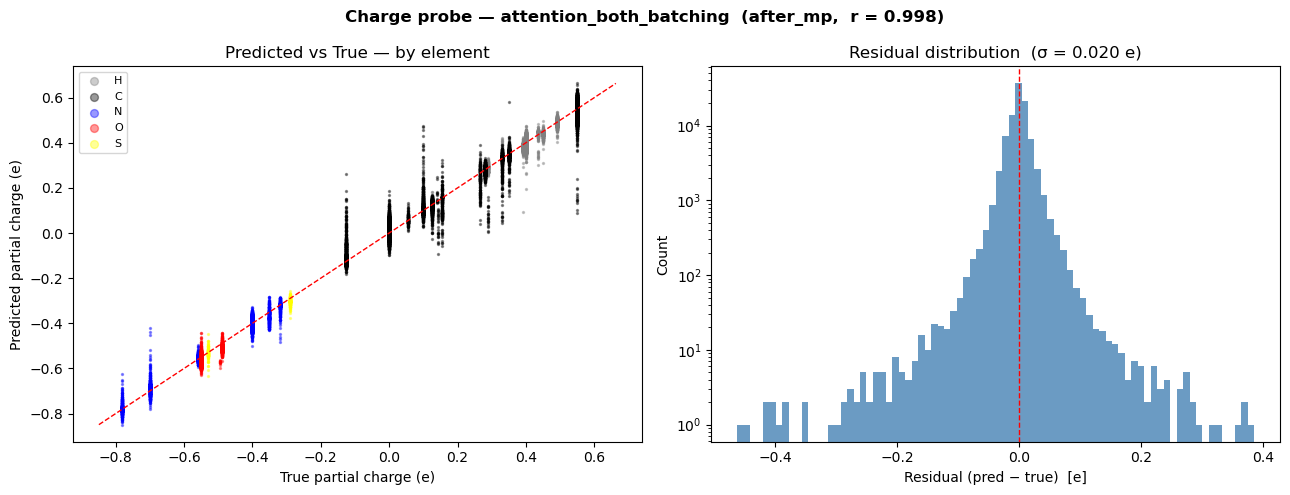

In [15]:
if not PROBE_MODEL.exists():
    print(f"Checkpoint not found: {PROBE_MODEL}")
else:
    all_true, all_pred, all_elem = [], [], []

    charge_probe_gpu = charge_probe.to(DEVICE)
    charge_probe_gpu.eval()
    with torch.no_grad():
        for pid in test_ids:
            paths = ProteinPaths(pid, DATA_ROOT)
            if not paths.pqr_path.exists():
                continue
            charges = read_pqr_charges(paths.pqr_path)
            data    = _load_graph(pid, DATA_ROOT)
            h_atom  = extract_atom_embeddings(probe_backbone, data, layer=PROBE_LAYER, device=DEVICE)
            if h_atom.shape[0] != len(charges):
                continue
            pred = charge_probe_gpu(h_atom.to(DEVICE)).cpu().numpy()
            all_true.extend(charges.tolist())
            all_pred.extend(pred.tolist())
            all_elem.extend(data["atom"].atom_type.cpu().numpy().tolist())

    t = np.array(all_true)
    p = np.array(all_pred)
    e = np.array(all_elem)
    r = float(np.corrcoef(t, p)[0, 1])

    elem_colors = {0: "gray", 1: "black", 2: "blue", 3: "red", 4: "yellow", 5: "orange", 6: "purple"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Charge probe — {PROBE_MODEL.name}  ({PROBE_LAYER},  r = {r:.3f})",
                 fontsize=12, fontweight="bold")

    ax = axes[0]
    for idx, name in enumerate(ELEMENT_NAMES):
        mask = e == idx
        if mask.any():
            ax.scatter(t[mask], p[mask], s=2, alpha=0.4, color=elem_colors[idx],
                       label=name, rasterized=True)
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_xlabel("True partial charge (e)")
    ax.set_ylabel("Predicted partial charge (e)")
    ax.set_title("Predicted vs True — by element")
    ax.legend(loc="upper left", fontsize=8, markerscale=4)

    ax = axes[1]
    residuals = p - t
    ax.hist(residuals, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.set_xlabel("Residual (pred − true)  [e]")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.set_title(f"Residual distribution  (σ = {residuals.std():.3f} e)")

    plt.tight_layout()
    plt.show()

### 2b. Per chemical environment accuracy

Groups atoms by chemical role (backbone carbonyl C, aromatic C, hydroxyl O, carboxylate O, etc.) and reports probe RMSE, MAE, and Pearson r per group.

**Note on NaN correlations:** Several environments have zero charge variance because the PARSE forcefield assigns a fixed charge to all atoms of that type (e.g., all backbone carbonyl oxygens are −0.55 e, all Lys NZ are −0.32 e). Pearson r is undefined in this case — a low RMSE with NaN r means the probe is accurately predicting a constant, not that it is failing.

**Note on low r at near-zero variance:** Backbone carbonyl C (std=0.026 e) shows RMSE=0.032 but r=0.376 — the absolute error is small relative to the charge scale but correlation is near-zero because there is almost nothing to correlate. The same applies to carboxylate O side chain (std=0.007 e, r=0.523).

In [16]:
_AROMATIC: dict[str, set] = {
    "PHE": {"CG", "CD1", "CD2", "CE1", "CE2", "CZ"},
    "TYR": {"CG", "CD1", "CD2", "CE1", "CE2", "CZ"},
    "HIS": {"CG", "ND1", "CD2", "CE1", "NE2"},
    "TRP": {"CG", "CD1", "CD2", "NE1", "CE2", "CE3", "CZ2", "CZ3", "CH2"},
}


def classify_atom(atom_name: str, res_name: str) -> str:
    if atom_name == "CA":                          return "Cα (backbone)"
    if atom_name == "C":                           return "Carbonyl C (backbone)"
    if atom_name == "O":                           return "Carbonyl O (backbone)"
    if atom_name == "N":                           return "Amide N (backbone)"
    if atom_name in {"OXT", "OT1", "OT2"}:        return "Carboxylate O (C-term)"
    if res_name in _AROMATIC and atom_name in _AROMATIC[res_name]:
        return "Aromatic N" if atom_name.startswith("N") else "Aromatic C"
    if atom_name in {"OG", "OG1", "OH"}:           return "Hydroxyl O"
    if res_name in {"ASP", "GLU"} and atom_name in {"OD1", "OD2", "OE1", "OE2"}:
        return "Carboxylate O (side chain)"
    if res_name in {"ASN", "GLN"} and atom_name in {"OD1", "OE1"}:
        return "Amide O (side chain)"
    if res_name in {"ASN", "GLN"} and atom_name in {"ND2", "NE2"}:
        return "Amide N (side chain)"
    if res_name == "LYS" and atom_name == "NZ":    return "Amine N (Lys)"
    if res_name == "ARG" and atom_name in {"NH1", "NH2", "NE"}: return "Guanidinium N (Arg)"
    if res_name == "PRO" and atom_name == "N":     return "Imino N (Pro)"
    if atom_name.startswith("S"):                  return "Sulfur"
    if atom_name.startswith("C"):                  return "Aliphatic C"
    if atom_name.startswith("N"):                  return "Other N"
    if atom_name.startswith("O"):                  return "Other O"
    if atom_name[0] in {"H", "D"}:                return "H"
    return "Other"


print("Classifier ready.")

Classifier ready.


In [17]:
if not PROBE_MODEL.exists():
    print(f"Checkpoint not found: {PROBE_MODEL}")
else:
    from collections import defaultdict

    env_true = defaultdict(list)
    env_pred = defaultdict(list)

    charge_probe_gpu = charge_probe.to(DEVICE)
    charge_probe_gpu.eval()
    with torch.no_grad():
        for pid in test_ids:
            paths = ProteinPaths(pid, DATA_ROOT)
            if not paths.pqr_path.exists():
                continue
            charges, atom_names, res_names = read_pqr_atoms(paths.pqr_path)
            data   = _load_graph(pid, DATA_ROOT)
            h_atom = extract_atom_embeddings(probe_backbone, data, layer=PROBE_LAYER, device=DEVICE)
            if h_atom.shape[0] != len(charges):
                continue
            pred = charge_probe_gpu(h_atom.to(DEVICE)).cpu().numpy()
            for i, (aname, rname) in enumerate(zip(atom_names, res_names)):
                env = classify_atom(aname, rname)
                env_true[env].append(float(charges[i]))
                env_pred[env].append(float(pred[i]))

    env_rows = []
    for env in sorted(env_true.keys()):
        t_arr = np.array(env_true[env])
        p_arr = np.array(env_pred[env])
        n     = len(t_arr)
        rmse  = float(np.sqrt(np.mean((p_arr - t_arr) ** 2)))
        mae   = float(np.mean(np.abs(p_arr - t_arr)))
        if n > 1 and t_arr.std() > 0 and p_arr.std() > 0:
            r = float(np.corrcoef(t_arr, p_arr)[0, 1])
        else:
            r = float("nan")
        env_rows.append({
            "Environment":  env,
            "N atoms":      n,
            "Mean charge":  float(t_arr.mean()),
            "Charge std":   float(t_arr.std()),
            "RMSE":         rmse,
            "MAE":          mae,
            "Pearson r":    r,
        })

    df_env = pd.DataFrame(env_rows).sort_values("RMSE")
    pd.set_option("display.float_format", "{:.4f}".format)
    display(df_env)

,Environment,N atoms,Mean charge,Charge std,RMSE,MAE,Pearson r
13,H,47547,0.0977,0.1677,0.0115,0.0075,0.9977
1,Amide N (backbone),6174,-0.4099,0.0394,0.0161,0.0120,0.9206
9,Carboxylate O (C-term),20,-0.5500,0.0000,0.0171,0.0146,NaN
4,Amine N (Lys),391,-0.3200,0.0000,0.0186,0.0114,NaN
8,Carbonyl O (backbone),6174,-0.5500,0.0000,0.0198,0.0164,NaN
3,Amide O (side chain),454,-0.5500,0.0000,0.0219,0.0197,NaN
15,Sulfur,311,-0.3772,0.1154,0.0221,0.0165,0.9843
6,Aromatic N,374,-0.4583,0.0819,0.0224,0.0181,0.9702
10,Carboxylate O (side chain),1558,-0.5491,0.0071,0.0225,0.0207,0.5235
14,Hydroxyl O,1019,-0.4900,0.0000,0.0233,0.0205,NaN


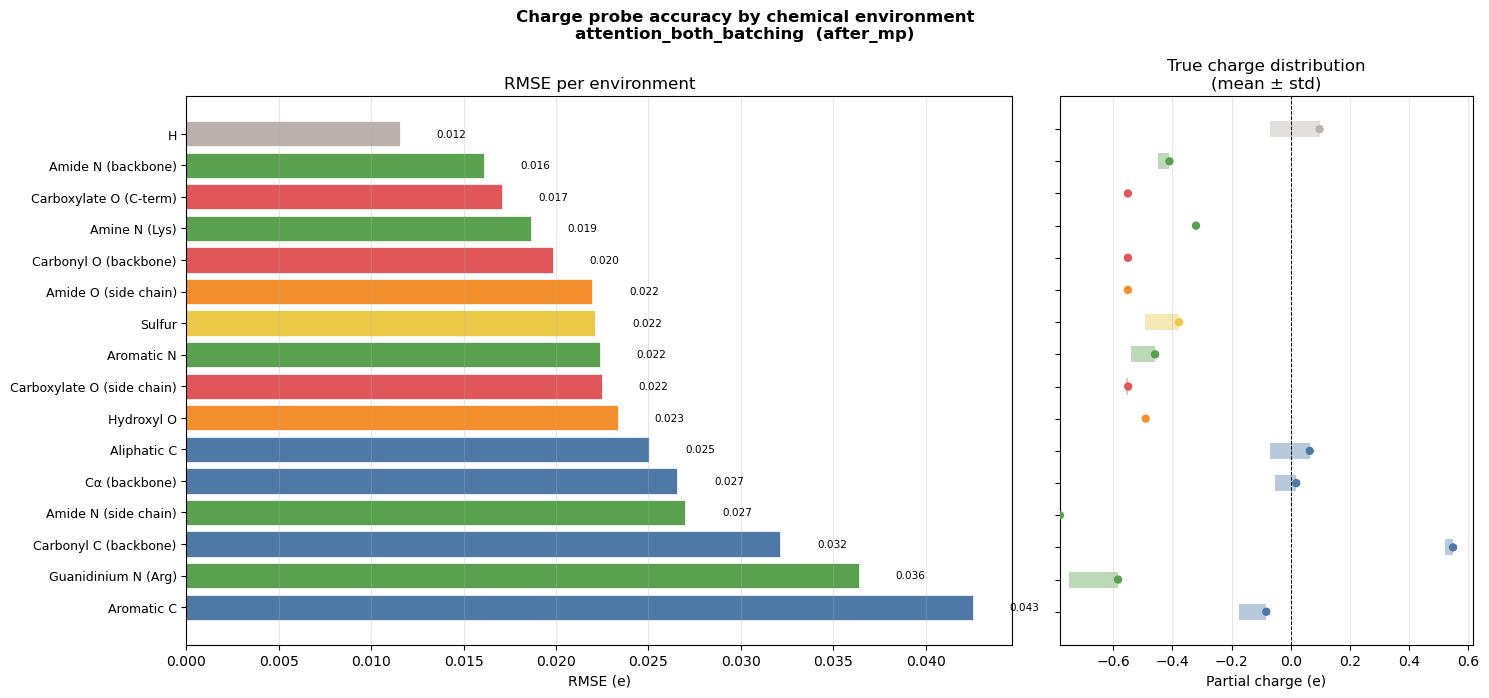

In [18]:
if not PROBE_MODEL.exists():
    print(f"Checkpoint not found: {PROBE_MODEL}")
else:
    plot_df = df_env[df_env["N atoms"] >= 20].sort_values("RMSE", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(plot_df) * 0.38 + 1)),
                             gridspec_kw={"width_ratios": [2, 1]})
    fig.suptitle(f"Charge probe accuracy by chemical environment\n"
                 f"{PROBE_MODEL.name}  ({PROBE_LAYER})", fontsize=12, fontweight="bold")

    y = np.arange(len(plot_df))

    def _env_color(env):
        if "C" in env and "O" not in env and "N" not in env: return "#4e79a7"
        if env.startswith("Carbonyl O") or env.startswith("Carboxylate O"): return "#e15759"
        if "Hydroxyl" in env or "Amide O" in env: return "#f28e2b"
        if "N" in env:  return "#59a14f"
        if "H" == env:  return "#bab0ac"
        if "Sulfur" in env: return "#edc948"
        return "#9c755f"

    colors_env = [_env_color(e) for e in plot_df["Environment"]]

    ax = axes[0]
    bars = ax.barh(y, plot_df["RMSE"], color=colors_env, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Environment"], fontsize=9)
    ax.set_xlabel("RMSE (e)")
    ax.set_title("RMSE per environment")
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, plot_df["RMSE"]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=7.5)

    ax = axes[1]
    ax.barh(y, plot_df["Charge std"], left=plot_df["Mean charge"] - plot_df["Charge std"],
            height=0.5, color=colors_env, alpha=0.4, label="±1 std")
    ax.scatter(plot_df["Mean charge"], y, color=colors_env, s=25, zorder=3)
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels([], fontsize=9)
    ax.set_xlabel("Partial charge (e)")
    ax.set_title("True charge distribution\n(mean ± std)")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Notes & Observations

### Partial charge probe — overall

A frozen-backbone MLP achieves **mean R² = 0.9947**, RMSE = 0.020 e across 95,435 atoms in 20 test proteins. Partial charges in PARSE range from approximately −0.78 e (amide N side chain) to +0.55 e (carbonyl C backbone), so a 0.020 e RMSE represents ~2.5% of the full charge range. This result means the atom embeddings — produced entirely by the `AtomEncoder` + Stage 1 bond/radial message passing — encode the chemical charge distribution the model is ultimately trained to predict.

The probe was trained for only 30 epochs from random initialisation with no fine-tuning of the backbone, and MSE converged from 0.0077 to 0.0004. This rapid convergence further confirms the embeddings carry a dense, linearly-accessible representation of charge.

### Per-environment highlights

- **H atoms** (RMSE=0.012, r=0.998, n=47,547): best-predicted environment. Hydrogen charges vary with their bonded heavy atom and are well-separated by element type — easily read from the embedding.
- **Backbone amide N** (RMSE=0.016, r=0.921): high accuracy; the backbone amide nitrogen is a consistent chemical environment across all proteins, making it easy to learn from bonded context.
- **Aromatic C** (RMSE=0.043, r=0.891, n=3,109): hardest environment with nonzero variance. Aromatic carbons span a range of partial charges depending on substituents (e.g., phenyl vs. indole vs. imidazole ring positions), requiring the embeddings to distinguish ring context — achievable but at higher error than aliphatic C.
- **Carbonyl C backbone** (RMSE=0.032, r=0.376): misleadingly low correlation — charge std is only 0.026 e, so the probe predicts a near-constant value correctly. Absolute accuracy is good; the correlation metric is uninformative here.
- **Guanidinium N in Arg** (RMSE=0.036, r=0.977): relatively high RMSE but high correlation — Arg guanidinium charges span a range across the three N atoms (NH1, NH2, NE differ in PARSE) and the embeddings track this well.

### Implications for the model

The charge probe confirms the model is not operating as a geometric interpolator. By the time representations reach Stage 2 (AQ transfer to query nodes), each atom carries sufficient chemical context for a linear probe to recover partial charges at near-perfect accuracy. Since ESP is directly determined by the distribution of partial charges, the model's internal representation is well-aligned with the physical quantity it is predicting.